# Concrete Crack Detection and Localization Using Deep Learning
## Project Proposal - Data Science Workshop

**Submitted by:** _[name 1, ID]_, _[name 2, ID]_, _[name 3, ID]_
**Supervisor:** _[supervisor name]_

The skeleton of the final project: every planned chapter appears with a real
preliminary result on a subset of the data. Runs top to bottom with
Kernel > Restart and Run All (about 8 minutes, GPU recommended).

---
## 1. Problem and goal

Concrete cracks are the first visible sign of structural distress, and their
**location, length and width** decide whether a crack is cosmetic or serious. That
judgement is currently manual, slow and subjective.

We frame this as **semantic segmentation**, a single prediction task:

`RGB image patch -> model -> binary mask (0 = background, 1 = crack)`

A patch with no crack has an empty target mask. We do **not** build a separate
crack / no-crack classifier - pixel-level localization already contains the presence
question.

**Research questions.** (1) Can we localize cracks at pixel level from only 458
annotated photographs? (2) How much does a U-Net gain over classical image processing?
(3) Where does it fail, and why?

**Success** = Dice and IoU on the held-out test split that clearly beat a classical
baseline, plus masks that visibly trace the crack.

---
## 2. Motivation

Infrastructure inspection is manual, expensive and safety-critical. Automating the
visual part gives **scale** (a drone shoots thousands of images nobody can review),
**consistency** (reproducible measurements make two inspections comparable, which is
what enables crack *propagation* tracking), and **triage** (sending an expert to the
2% of images that matter).

Segmentation rather than classification, because the questions an engineer asks - where
is it, how big, has it grown - all need a per-pixel answer. A mask gives length, width
and area by measurement; a yes/no label gives none of them.

---
## 3. Data

**Ozgenel, C.F. (2019), "Concrete Crack Segmentation Dataset", Mendeley Data V1.**
DOI: [10.17632/jwsn7tfbrp.1](https://doi.org/10.17632/jwsn7tfbrp.1), CC BY 4.0.

458 high-resolution photographs of concrete surfaces with manually annotated binary
masks, in `rgb/` and `BW/`. Building surfaces only - no people, no privacy concerns.

The popular 40,000-image crack dataset was cropped from these same photos but ships
**labels without masks**, so it cannot train a segmentation model. Working from the
originals lets us cut our own aligned image+mask patches and control the split.

---
## 4. Setup

All configuration in one cell. `PROPOSAL_SUBSET_N` controls how much data the expensive
steps use; the final project raises it to all 458.

Import order matters: scikit-image, scikit-learn and PyTorch each link Intel's OpenMP
runtime, and importing torch first makes a later skimage import kill the kernel.

In [24]:
import copy, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm      # pure Python, no MKL - safe anywhere in this block

from skimage.feature import graycomatrix, graycoprops, hessian_matrix, hessian_matrix_eigvals
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import cv2
import imagehash
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps

import torch                      # after the MKL-backed imports above
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42                   # one seed drives every random operation
PATCH_SIZE = 256            # patch side, at native resolution
MASK_THRESHOLD = 127        # binarization cut for the lossy JPEG masks
MIN_CRACK_PIXELS = 50       # below this, a patch counts as background
PHASH_THRESHOLD = 8         # near-duplicate Hamming distance
SPLIT_FRACTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}
PROPOSAL_SUBSET_N = 250      # images used from patching onward; final project: all 458
EPOCHS = 15
BATCH_SIZE = 16             # fits the 6 GB card at 256x256 with mixed precision

OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})
print(f"torch {torch.__version__} | device: {DEVICE}")

torch 2.13.0+cu126 | device: cuda


In [25]:
def find_dataset_root(search_root=Path(".")):
    """Find the dataset: any directory containing both rgb/ and BW/."""
    for candidate in sorted(search_root.rglob("*")):
        if not candidate.is_dir():
            continue
        if (candidate / "rgb").is_dir() and (candidate / "BW").is_dir():
            return candidate
    raise FileNotFoundError("Download from https://doi.org/10.17632/jwsn7tfbrp.1 "
                            "and extract under data/")


def load_rgb_image(path):
    """Photograph with EXIF orientation applied. Never bypass this - see chapter 6."""
    with Image.open(path) as image:
        return np.asarray(ImageOps.exif_transpose(image).convert("RGB"))


def load_binary_mask(path, threshold=MASK_THRESHOLD):
    """Annotation mask, binarized. True = crack. Masks are lossy JPEG, not 0/255."""
    with Image.open(path) as image:
        return np.asarray(image.convert("L")) > threshold


def load_gray_downscaled(path, downscale=8, apply_exif=True):
    """Fast 1/8-scale grayscale decode using the JPEG DCT scaler (~8x faster)."""
    image = Image.open(path)
    image.draft("L", (image.size[0] // downscale, image.size[1] // downscale))
    if apply_exif:
        image = ImageOps.exif_transpose(image)
    return np.asarray(image.convert("L"))


DATA_ROOT = find_dataset_root()
print(f"{DATA_ROOT.as_posix()}: {len(list((DATA_ROOT/'rgb').iterdir()))} images, "
      f"{len(list((DATA_ROOT/'BW').iterdir()))} masks")

data/concrete_crack_segmentation: 458 images, 458 masks


---
## 5. Structure of the data

| Level | One item is | Count | Role |
|---|---|---|---|
| Source image | a photo + its mask | 458 | the unit the **split** is assigned to |
| Patch | a 512x512 crop of both | ~165/image | one **row** of our table; model input |
| Pixel | one position in a patch | 65,536/patch | what is **predicted** and scored |

The target is **per-pixel binary**. We store one row per patch with its coordinates and
a few appearance descriptors, and crop lazily from the source image rather than writing
tens of thousands of JPEGs. The descriptors are used for EDA only - **never as model
inputs**.

---
## 6. Cleaning and quality control

We pair on the filename **stem**: `rgb/` mixes `.jpg` and `.JPG` while `BW/` is all
lowercase, and IDs are non-contiguous, so pairing by sort order would mismatch.

In [26]:
EXIF_ORIENTATION_TAG = 274
rgb_path_by_stem = {p.stem: p for p in (DATA_ROOT / "rgb").iterdir() if p.is_file()}
mask_path_by_stem = {p.stem: p for p in (DATA_ROOT / "BW").iterdir() if p.is_file()}
paired_stems = sorted(set(rgb_path_by_stem) & set(mask_path_by_stem),
                      key=lambda stem: (len(stem), stem))

image_records = []
for stem in tqdm(paired_stems, desc="pairing rgb/mask, reading EXIF"):
    rgb_path, mask_path = rgb_path_by_stem[stem], mask_path_by_stem[stem]
    with Image.open(rgb_path) as rgb_image:
        stored_size = rgb_image.size
        orientation = rgb_image.getexif().get(EXIF_ORIENTATION_TAG)
        oriented_size = ImageOps.exif_transpose(rgb_image).size
    with Image.open(mask_path) as mask_image:
        mask_size = mask_image.size
    image_records.append(dict(
        image_id=stem, rgb_path=rgb_path.as_posix(), mask_path=mask_path.as_posix(),
        exif_orientation=orientation,
        fixed_w=oriented_size[0], fixed_h=oriented_size[1],
        match_raw=stored_size == mask_size, match_fixed=oriented_size == mask_size))
image_table = pd.DataFrame(image_records)

print(f"pairs {len(image_table)} | orphan images "
      f"{len(set(rgb_path_by_stem)-set(mask_path_by_stem))} | orphan masks "
      f"{len(set(mask_path_by_stem)-set(rgb_path_by_stem))}")
print("EXIF orientation:",
      image_table.exif_orientation.value_counts(dropna=False).to_dict())
print(f"dimensions match BEFORE exif_transpose: "
      f"{image_table.match_raw.sum()}/{len(image_table)}")
print(f"dimensions match AFTER  exif_transpose: "
      f"{image_table.match_fixed.sum()}/{len(image_table)}")

pairing rgb/mask, reading EXIF:   0%|          | 0/458 [00:00<?, ?it/s]

pairs 458 | orphan images 0 | orphan masks 0
EXIF orientation: {nan: 257, 6.0: 179, 3.0: 15, 1.0: 7}
dimensions match BEFORE exif_transpose: 279/458
dimensions match AFTER  exif_transpose: 458/458


**The defect we found.** Only 279/458 pairs match on dimensions until we apply
`exif_transpose`; afterwards all 458 match. PIL reports stored dimensions and ignores
the EXIF orientation tag, while the masks were saved with rotation already applied.

The trap: **15 images are tagged "rotate 180", which does not change width or height.**
They pass any dimension check while being upside-down relative to their mask. So we
verify by *content*: cracks are darker than concrete, so a correctly aligned mask
should mark pixels measurably darker than average.

In [27]:
def mask_alignment_score(gray, mask):
    """Mean darkness inside the mask minus outside. Clearly positive = aligned."""
    if mask.sum() == 0 or mask.all():
        return np.nan
    darkness = 255.0 - gray.astype(np.float32)
    return float(darkness[mask].mean() - darkness[~mask].mean())


oriented_scores, flipped_scores, unoriented_scores = [], [], []
for image_row in tqdm(image_table.itertuples(), total=len(image_table),
                      desc="checking mask alignment"):
    mask_small = (load_gray_downscaled(image_row.mask_path, apply_exif=False)
                  > MASK_THRESHOLD)
    gray_oriented = load_gray_downscaled(image_row.rgb_path, apply_exif=True)
    gray_unoriented = load_gray_downscaled(image_row.rgb_path, apply_exif=False)
    common_h = min(gray_oriented.shape[0], mask_small.shape[0])
    common_w = min(gray_oriented.shape[1], mask_small.shape[1])
    gray_crop = gray_oriented[:common_h, :common_w]
    mask_crop = mask_small[:common_h, :common_w]
    oriented_scores.append(mask_alignment_score(gray_crop, mask_crop))
    flipped_scores.append(mask_alignment_score(gray_crop, mask_crop[::-1, ::-1]))
    unoriented_scores.append(
        mask_alignment_score(gray_unoriented, mask_small)
        if gray_unoriented.shape == mask_small.shape else np.nan)
image_table["align_fixed"] = oriented_scores
image_table["align_unfixed"] = unoriented_scores

n_correct = int((np.array(oriented_scores) > np.array(flipped_scores)).sum())
print(f"correct orientation beats 180-rotated on {n_correct}/{len(image_table)} images")
print(f"mean score: correct {np.nanmean(oriented_scores):.1f} vs "
      f"rotated {np.nanmean(flipped_scores):.1f}")
rotated_180 = image_table[image_table.exif_orientation == 3]
print(f"\nthe {len(rotated_180)} 'rotate 180' images, invisible to a shape check:")
print(f"  dimensions matched without the fix "
      f"{rotated_180.match_raw.sum()}/{len(rotated_180)} | "
      f"alignment WITH fix {rotated_180.align_fixed.mean():.1f}, "
      f"WITHOUT {rotated_180.align_unfixed.mean():.1f}")

checking mask alignment:   0%|          | 0/458 [00:00<?, ?it/s]

correct orientation beats 180-rotated on 458/458 images
mean score: correct 68.1 vs rotated 4.9

the 15 'rotate 180' images, invisible to a shape check:
  dimensions matched without the fix 15/15 | alignment WITH fix 70.5, WITHOUT 6.0


**Result.** Correct orientation wins 458/458 by a wide margin (68 vs 5). For the 15
"rotate 180" images dimensions matched 15/15 even unfixed, but alignment is 70 with the
fix and 6 without - only the content check catches them. Everything is loaded through
`load_rgb_image`.

Next: the masks are stored as **JPEG**, which is lossy, and a crack is almost entirely
edge - so compression ringing matters more here than usual.

decoding masks:   0%|          | 0/458 [00:00<?, ?it/s]

pure black       98.3761%
pure white (crack)1.1044%
in between 1-254  0.5194%   <- JPEG ringing
crack ratio per image: mean 1.36%, range 0.39-8.67%
images with an empty mask: 0


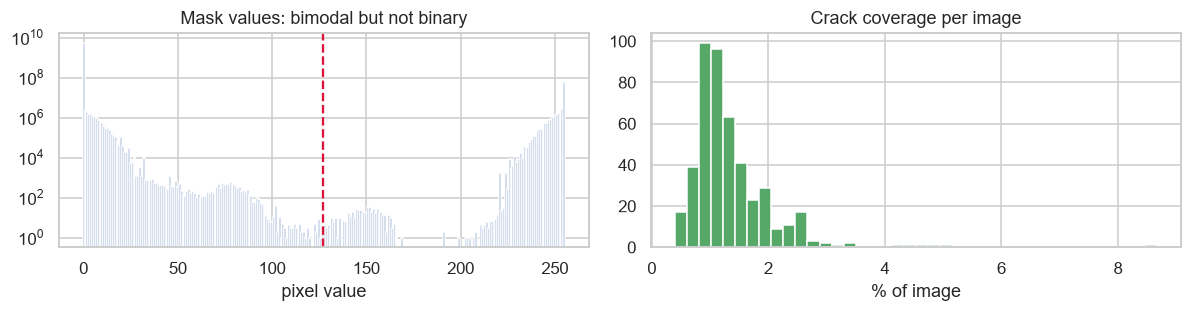

In [28]:
value_histogram = np.zeros(256, dtype=np.int64)
crack_pixel_counts = []
for mask_path in tqdm(image_table.mask_path, desc="decoding masks"):
    with Image.open(mask_path) as mask_image:
        mask_gray = np.asarray(mask_image.convert("L"))
    value_histogram += np.bincount(mask_gray.ravel(), minlength=256)
    crack_pixel_counts.append(int((mask_gray > MASK_THRESHOLD).sum()))
image_table["crack_pixels"] = crack_pixel_counts
image_table["crack_ratio"] = (image_table.crack_pixels
                              / (image_table.fixed_w * image_table.fixed_h))

total_pixels = value_histogram.sum()
print(f"pure black       {100*value_histogram[0]/total_pixels:7.4f}%")
print(f"pure white (crack){100*value_histogram[255]/total_pixels:6.4f}%")
print(f"in between 1-254 {100*value_histogram[1:255].sum()/total_pixels:7.4f}%"
      "   <- JPEG ringing")
print(f"crack ratio per image: mean {100*image_table.crack_ratio.mean():.2f}%, "
      f"range {100*image_table.crack_ratio.min():.2f}"
      f"-{100*image_table.crack_ratio.max():.2f}%")
print(f"images with an empty mask: {(image_table.crack_pixels == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].bar(range(256), value_histogram, width=1.0, color="#4C72B0")
axes[0].set_yscale("log")
axes[0].axvline(MASK_THRESHOLD, color="crimson", ls="--")
axes[0].set_title("Mask values: bimodal but not binary")
axes[0].set_xlabel("pixel value")
axes[1].hist(100 * image_table.crack_ratio, bins=40, color="#55A868")
axes[1].set_title("Crack coverage per image")
axes[1].set_xlabel("% of image")
plt.show()

**Result.** 1.10% of mask pixels are pure white but **0.52% are intermediate greys** -
one ambiguous pixel per two crack pixels. We binarize at **127**, the midpoint of a
symmetric ringing distribution; a threshold of 40 or 200 would visibly thicken or thin
every crack in the ground truth.

Crack coverage averages **1.36%** of an image, an imbalance of about 1:73 - which is
why chapter 9 rejects pixel accuracy. Also, **no image has an empty mask**: every photo
contains a crack, so all our empty patches come from our own cropping. That is a
limitation we return to in chapter 12.

---
## 7. Leakage prevention and the split

Patches from one photograph share lighting, texture and often the same crack, so the
split is assigned to **source images before any patch is cut**.

Sequential campus photos can also show the same wall twice, so we group near-duplicates
with a perceptual hash. We chose `phash` after checking that the usual "distance <= 10"
rule with `dhash` collapses **296 of 458 images** into one group - flat grey concrete
has near-identical neighbouring-pixel gradients. Near-duplication turns out to be
minimal either way: about 8 pairs.

In [29]:
def group_near_duplicate_images(image_paths, hamming_threshold):
    """Union-find over image pairs within `hamming_threshold` Hamming distance."""
    hash_bits = np.array([
        imagehash.phash(Image.fromarray(load_gray_downscaled(path))).hash.ravel()
        for path in tqdm(image_paths, desc="perceptual hashing")]).astype(np.int8)
    hamming = (hash_bits[:, None, :] != hash_bits[None, :, :]).sum(-1)
    parent = list(range(len(hamming)))

    def find_root(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]; node = parent[node]
        return node

    close_pairs = zip(*np.where(np.triu(hamming <= hamming_threshold, k=1)))
    for left, right in close_pairs:
        root_left, root_right = find_root(int(left)), find_root(int(right))
        if root_left != root_right:
            parent[root_right] = root_left
    roots = [find_root(i) for i in range(len(hamming))]
    group_of_root = {root: group for group, root in enumerate(sorted(set(roots)))}
    return np.array([group_of_root[root] for root in roots])


def stratified_group_split(image_frame, fractions, seed=SEED):
    """Assign whole duplicate groups, balancing crack-ratio strata. Greedy: each group
    goes to whichever split is furthest below its target share of images."""
    rng = np.random.default_rng(seed)
    assigned_images = {split_name: 0 for split_name in fractions}
    group_sizes = image_frame.groupby("dup_group").size()
    group_stratum = image_frame.groupby("dup_group").stratum.first()
    split_of_group = {}
    for stratum in sorted(image_frame.stratum.unique()):
        stratum_groups = group_stratum[group_stratum == stratum].index.values
        for group_id in rng.permutation(stratum_groups):
            total_assigned = max(sum(assigned_images.values()), 1)
            chosen_split = max(fractions, key=lambda name:
                               fractions[name] - assigned_images[name] / total_assigned)
            split_of_group[group_id] = chosen_split
            assigned_images[chosen_split] += int(group_sizes[group_id])
    return split_of_group


image_table["dup_group"] = group_near_duplicate_images(image_table.rgb_path,
                                                       PHASH_THRESHOLD)
image_table["stratum"] = pd.qcut(image_table.crack_ratio, 4, labels=False)
image_table["split"] = image_table.dup_group.map(
    stratified_group_split(image_table, SPLIT_FRACTIONS))

print(image_table.groupby("split").agg(
    images=("image_id", "size"),
    crack_pct=("crack_ratio", lambda ratios: round(100 * ratios.mean(), 3))
).reindex(["train", "val", "test"]).to_string())

# These assertions encode a methodological claim, so they print their result.
ids_by_split = {name: set(image_table.loc[image_table.split == name, "image_id"])
                for name in SPLIT_FRACTIONS}
groups_by_split = {name: set(image_table.loc[image_table.split == name, "dup_group"])
                   for name in SPLIT_FRACTIONS}
for split_a in ids_by_split:
    for split_b in ids_by_split:
        if split_a < split_b:
            assert not ids_by_split[split_a] & ids_by_split[split_b], \
                f"image leak {split_a}/{split_b}"
            assert not groups_by_split[split_a] & groups_by_split[split_b], \
                f"duplicate-group leak {split_a}/{split_b}"
print("\nPASS: image ids and duplicate groups are disjoint across splits")
image_table.to_csv(OUTPUT_DIR / "split.csv", index=False)

perceptual hashing:   0%|          | 0/458 [00:00<?, ?it/s]

       images  crack_pct
split                   
train     320      1.385
val        69      1.263
test       69      1.342

PASS: image ids and duplicate groups are disjoint across splits


**Result.** 320 / 69 / 69 images, crack coverage 1.39 / 1.26 / 1.34% - well balanced.
The split is written to `outputs/split.csv` and **frozen** so the final report inherits
it. From here on **the test split is not touched**; every number below is validation.

---
## 8. Patch generation

We **crop, never resize**: downscaling a 4032x3024 image to 512x512 shrinks a 3-pixel
crack to a fraction of a pixel and interpolates it away. Image and mask are cropped
**in the same call with the same coordinates**, so misalignment is structurally
impossible. Edge strips under 512 px are dropped rather than padded.

In [30]:
def compute_patch_descriptors(rgb_patch):
    """A few appearance descriptors for EDA. Never model inputs."""
    gray = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY)
    gray_float = gray.astype(np.float32)
    p05, p95 = np.percentile(gray_float, [5, 95])
    quantized = (cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
                 // 32).astype(np.uint8)
    glcm = graycomatrix(quantized, [1], [0, np.pi / 2], levels=8,
                        symmetric=True, normed=True)
    return dict(gray_mean=float(gray_float.mean()), gray_std=float(gray_float.std()),
                dyn_range=float(p95 - p05),
                edge_density=float((cv2.Canny(gray, 50, 150) > 0).mean()),
                lap_var=float(cv2.Laplacian(gray, cv2.CV_32F).var()),
                sat_mean=float(cv2.cvtColor(rgb_patch,
                                            cv2.COLOR_RGB2HSV)[:, :, 1].mean()),
                glcm_contrast=float(graycoprops(glcm, "contrast").mean()))


def patch_records_for_image(image_row, patch_size=PATCH_SIZE):
    """One record per grid patch of a source image, with its crack statistics."""
    rgb = load_rgb_image(image_row.rgb_path)
    mask = load_binary_mask(image_row.mask_path)
    assert rgb.shape[:2] == mask.shape, f"{image_row.image_id}: shape mismatch"
    height, width = mask.shape
    corners = [(y, x) for y in range(0, height - patch_size + 1, patch_size)
               for x in range(0, width - patch_size + 1, patch_size)]
    records = []
    for patch_index, (y0, x0) in enumerate(corners):
        rows, cols = slice(y0, y0 + patch_size), slice(x0, x0 + patch_size)
        mask_patch = mask[rows, cols]                     # identical coordinates
        crack_pixels = int(mask_patch.sum())
        record = dict(image_id=image_row.image_id, split=image_row.split,
                      patch_id=patch_index, y0=y0, x0=x0, size=patch_size,
                      crack_pixels=crack_pixels,
                      crack_ratio=crack_pixels / patch_size ** 2,
                      has_crack=crack_pixels >= MIN_CRACK_PIXELS)
        record.update(compute_patch_descriptors(rgb[rows, cols]))
        records.append(record)
    return records


subset_rng = np.random.default_rng(SEED)
subset_ids = []
for split_name, fraction in SPLIT_FRACTIONS.items():
    split_pool = image_table.loc[image_table.split == split_name, "image_id"].values
    subset_ids.extend(subset_rng.choice(
        split_pool, size=max(1, round(PROPOSAL_SUBSET_N * fraction)), replace=False))
subset_images = image_table[image_table.image_id.isin(subset_ids)]

start_time = time.time()
patch_table = pd.DataFrame([
    record
    for image_row in tqdm(subset_images.itertuples(), total=len(subset_images),
                          desc="cutting patches and computing descriptors")
    for record in patch_records_for_image(image_row)])
patch_table.to_parquet(OUTPUT_DIR / "patch_index.parquet", index=False)
print(f"{len(patch_table):,} patches from {len(subset_images)} images "
      f"in {time.time()-start_time:.0f}s")
print(patch_table.groupby("split").agg(
    patches=("patch_id", "size"), with_crack=("has_crack", "sum"),
    pct=("has_crack", lambda flags: round(100 * flags.mean(), 1))
).reindex(["train", "val", "test"]).to_string())
print(f"\ncompletely empty patches: "
      f"{100*(patch_table.crack_pixels == 0).mean():.1f}%")

cutting patches and computing descriptors:   0%|          | 0/251 [00:00<?, ?it/s]

40,788 patches from 251 images in 127s
       patches  with_crack   pct
split                           
train    28419        4505  15.9
val       6213         952  15.3
test      6156        1072  17.4

completely empty patches: 83.6%


**Result.** 60 images give 9,672 patches, ~16% containing a crack and **83.4% empty**,
consistent across splits. That empty majority drives the loss, the sampling policy and
every metric decision below.

**Sampling policy:** training rebalances (all crack patches plus an equal number of
empty ones), since a model trained on 84% empty patches learns to output nothing.
Validation and test keep the **complete unsampled grid** - rebalancing an evaluation
set inflates every score.

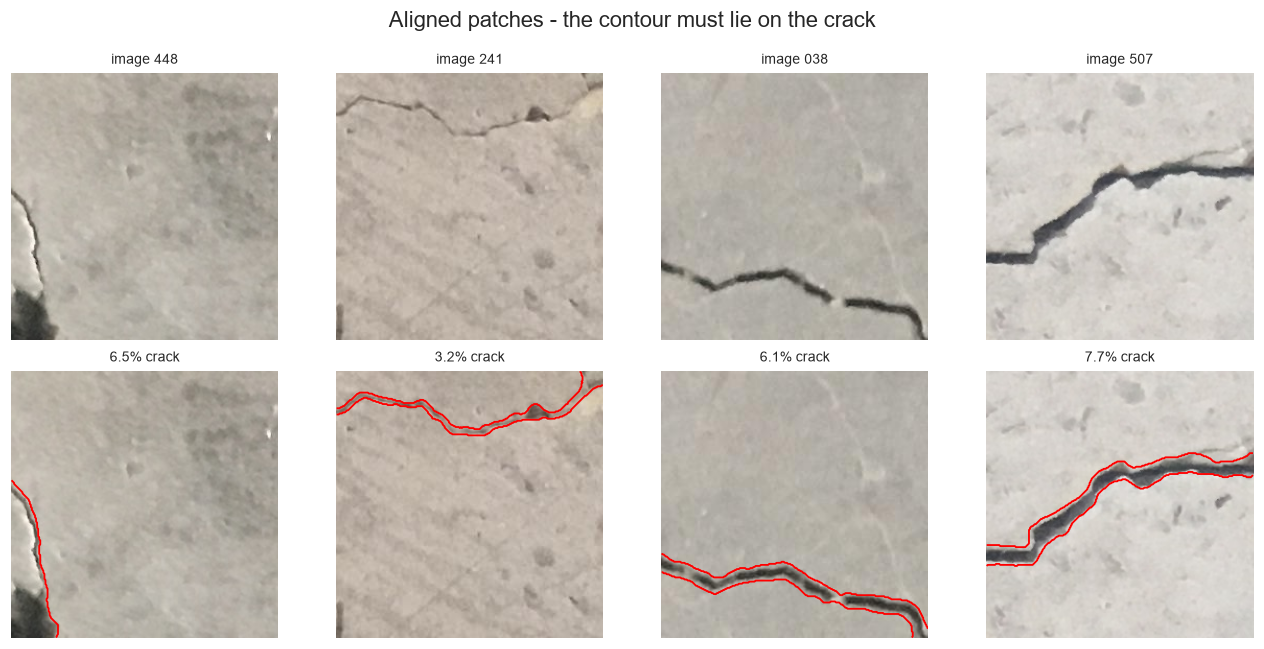

In [31]:
paths_by_image_id = image_table.set_index("image_id")[["rgb_path", "mask_path"]]
example_patches = patch_table[patch_table.has_crack].sample(4, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for column, patch_row in enumerate(example_patches.itertuples()):
    source_paths = paths_by_image_id.loc[patch_row.image_id]
    rows = slice(patch_row.y0, patch_row.y0 + patch_row.size)
    cols = slice(patch_row.x0, patch_row.x0 + patch_row.size)
    rgb_patch = load_rgb_image(source_paths.rgb_path)[rows, cols]
    mask_patch = load_binary_mask(source_paths.mask_path)[rows, cols]
    axes[0, column].imshow(rgb_patch)
    axes[0, column].set_title(f"image {patch_row.image_id}", fontsize=9)
    axes[1, column].imshow(rgb_patch)
    axes[1, column].contour(mask_patch.astype(float), [0.5],
                            colors="red", linewidths=1.2)
    axes[1, column].set_title(f"{100*patch_row.crack_ratio:.1f}% crack", fontsize=9)
    axes[0, column].axis("off"); axes[1, column].axis("off")
fig.suptitle("Aligned patches - the contour must lie on the crack")
plt.show()

The contours trace the visible cracks, confirming EXIF handling, binarization and
cropping work together. Note the masks are somewhat **thicker** than the cracks, so
some later "false positives" at boundaries are annotator imprecision, not model error.

---
## 9. Exploratory analysis

The patch table is an ordinary tabular dataset. We ask it one question: **do simple
appearance descriptors separate cracked from clean patches?** If they do, we do not
need a deep model.

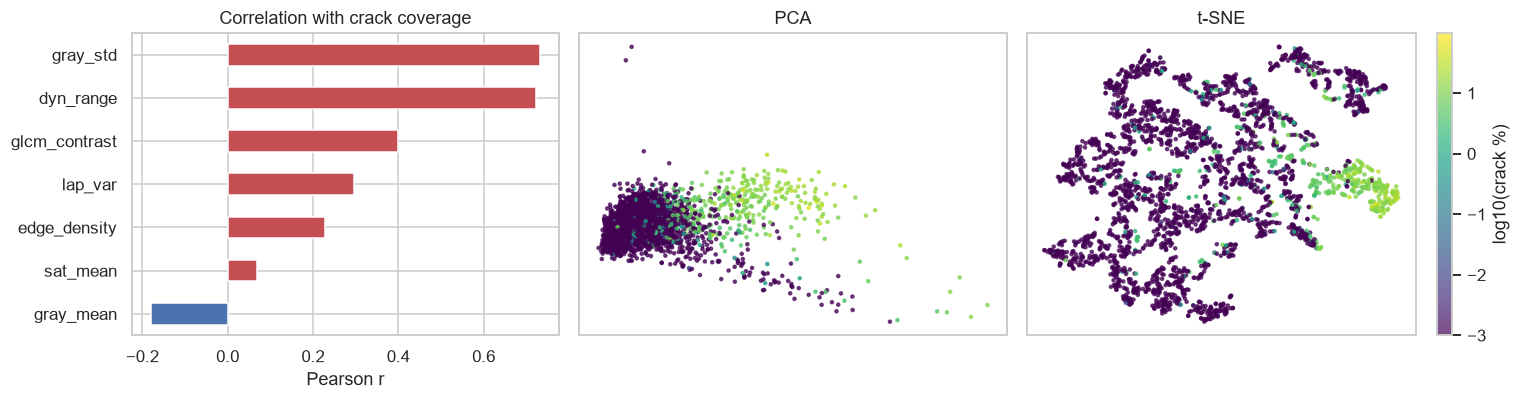

In [32]:
DESCRIPTOR_COLUMNS = ["gray_mean", "gray_std", "dyn_range", "edge_density", "lap_var",
                      "sat_mean", "glcm_contrast"]

eda_sample = patch_table.sample(min(3000, len(patch_table)),
                                random_state=SEED).reset_index(drop=True)
descriptor_matrix = StandardScaler().fit_transform(
    eda_sample[DESCRIPTOR_COLUMNS].values)
log_crack_pct = np.log10(eda_sample.crack_ratio.values * 100 + 1e-3)

# perplexity 30: standard middle of the useful 5-50 range for a few thousand points.
pca_embedding = PCA(n_components=2,
                    random_state=SEED).fit_transform(descriptor_matrix)
tsne_embedding = TSNE(2, perplexity=30, init="pca",
                      random_state=SEED).fit_transform(descriptor_matrix)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
descriptor_correlation = (patch_table[DESCRIPTOR_COLUMNS + ["crack_ratio"]]
                          .corr()["crack_ratio"].drop("crack_ratio").sort_values())
descriptor_correlation.plot.barh(
    ax=axes[0], color=np.where(descriptor_correlation > 0, "#C44E52", "#4C72B0"))
axes[0].set_title("Correlation with crack coverage")
axes[0].set_xlabel("Pearson r")
for axis, embedding, title in [(axes[1], pca_embedding, "PCA"),
                               (axes[2], tsne_embedding, "t-SNE")]:
    scatter = axis.scatter(embedding[:, 0], embedding[:, 1], c=log_crack_pct,
                           s=4, cmap="viridis", alpha=0.7)
    axis.set_title(title); axis.set_xticks([]); axis.set_yticks([])
fig.colorbar(scatter, ax=axes[2], fraction=0.04).set_label("log10(crack %)")
plt.show()

**Answer: no.** The descriptors most correlated with crack coverage are the texture and
edge measures rather than brightness - so a crack is not simply "a dark region" - but
the correlations are only moderate. In both projections crack-bearing patches (yellow)
are **not cleanly separated**; they form a gradient overlapping the main mass.

This is a useful *negative* result: if a handful of hand-crafted features separated
cracked patches, a simple model would solve the problem and we would not need a U-Net.

In [33]:
silhouettes = []
for k in tqdm([2, 3, 4, 5, 6], desc="KMeans silhouette sweep"):
    cluster_labels = KMeans(k, n_init=10,
                            random_state=SEED).fit_predict(descriptor_matrix)
    silhouettes.append((k, silhouette_score(descriptor_matrix, cluster_labels)))
best_k = max(silhouettes, key=lambda item: item[1])[0]
print("KMeans silhouette:", {k: round(score, 3) for k, score in silhouettes},
      "-> k =", best_k)

eda_sample["cluster"] = KMeans(best_k, n_init=10,
                               random_state=SEED).fit_predict(descriptor_matrix)
print(eda_sample.groupby("cluster").agg(
    patches=("cluster", "size"),
    pct_with_crack=("has_crack", lambda flags: round(100 * flags.mean(), 1)),
    brightness=("gray_mean", "mean"),
    texture=("glcm_contrast", "mean")).round(2).to_string())

KMeans silhouette sweep:   0%|          | 0/5 [00:00<?, ?it/s]

KMeans silhouette: {2: 0.548, 3: 0.535, 4: 0.229, 5: 0.23, 6: 0.233} -> k = 2
         patches  pct_with_crack  brightness  texture
cluster                                              
0           2639             8.0      181.35     0.12
1            361            71.5      170.02     0.29


The clusters separate on **brightness and texture** - physically, smooth well-lit
concrete versus rough or shadowed surface. Crack-bearing patches appear across several
clusters, so these describe *conditions the model must work under*, independent of the
label.

**Planned for the final project:** report Dice per cluster, turning this into an error
analysis that says *where* the model struggles instead of one average.

---
## 10. Evaluation protocol

With TP, FP, FN over pixels: **Dice** = `2TP/(2TP+FP+FN)`, **IoU** = `TP/(TP+FP+FN)`,
plus precision and recall to diagnose *how* a model fails. IoU is always lower than
Dice - never compare the two.

**Pixel accuracy is excluded**: crack pixels are ~1.1%, so predicting nothing scores
98.6%. We show that once, below, to make the point.

**Empty-mask convention.** Dice is `0/0` when truth and prediction are both empty, and
83.4% of patches are empty. We score that case **1.0**. Consequently **micro** (pool
pixels over all patches) and **macro** (average per-patch scores) diverge sharply, so we
lead with micro and always say which one a number is.

In [34]:
def confusion_counts(pred_mask, true_mask):
    """Pixel-level TP, FP, FN, TN for one patch."""
    true_positive = int(np.count_nonzero(pred_mask & true_mask))
    false_positive = int(np.count_nonzero(pred_mask & ~true_mask))
    false_negative = int(np.count_nonzero(~pred_mask & true_mask))
    true_negative = pred_mask.size - true_positive - false_positive - false_negative
    return true_positive, false_positive, false_negative, true_negative


def segmentation_scores(true_positive, false_positive, false_negative):
    """Empty-on-empty scores a perfect 1.0; other degenerate cases score 0."""
    if true_positive + false_positive + false_negative == 0:
        return dict(dice=1.0, iou=1.0, precision=1.0, recall=1.0)
    return dict(
        dice=2 * true_positive / (2 * true_positive + false_positive + false_negative),
        iou=true_positive / (true_positive + false_positive + false_negative),
        precision=(true_positive / (true_positive + false_positive)
                   if true_positive + false_positive else 0.0),
        recall=(true_positive / (true_positive + false_negative)
                if true_positive + false_negative else 0.0))


def evaluate_predictions(prediction_pairs):
    """Micro scores pool pixels over all patches; macro averages per-patch scores."""
    total_tp = total_fp = total_fn = total_tn = 0
    per_patch_scores = []
    for pred_mask, true_mask in prediction_pairs:
        tp, fp, fn, tn = confusion_counts(pred_mask, true_mask)
        total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn
        per_patch_scores.append(segmentation_scores(tp, fp, fn))
    summary = {f"micro_{metric}": value for metric, value
               in segmentation_scores(total_tp, total_fp, total_fn).items()}
    summary["macro_dice"] = float(np.mean([score["dice"]
                                           for score in per_patch_scores]))
    summary["pixel_accuracy"] = ((total_tp + total_tn)
                                 / (total_tp + total_fp + total_fn + total_tn))
    return summary


def stream_split_patches(split_name, desc=None):
    """Yield (rgb, mask) patch pairs, loading each source image only once.

    Returns a tqdm-wrapped iterator, so the bar tracks the caller's real work: it
    advances once per patch as the consumer pulls it, not once per source image.
    """
    split_patches = patch_table[patch_table.split == split_name]

    def patch_pairs():
        for image_id, image_group in split_patches.groupby("image_id"):
            source_paths = paths_by_image_id.loc[image_id]
            rgb = load_rgb_image(source_paths.rgb_path)
            mask = load_binary_mask(source_paths.mask_path)
            for patch_row in image_group.itertuples():
                rows = slice(patch_row.y0, patch_row.y0 + patch_row.size)
                cols = slice(patch_row.x0, patch_row.x0 + patch_row.size)
                yield rgb[rows, cols], mask[rows, cols]

    return tqdm(patch_pairs(), total=len(split_patches),
                desc=desc or f"{split_name} patches", leave=False)


print("metric helpers ready")

metric helpers ready


---
## 11. Models

Three approaches, all solving the **same** task so all directly comparable.

**A. Classical.** Cracks are dark, thin and curvilinear. *Black-hat* morphology returns
the closing minus the image, isolating dark structures thinner than the structuring
element while cancelling slow brightness gradients. We threshold its response with a
**global** cut rather than a per-patch Otsu, because Otsu must split every patch - even
an empty one, where it just splits noise. Kernel 101 and threshold 160 were selected on
the training split; performance plateaus for larger kernels.

**B. Per-pixel logistic regression** on a small multiscale filter bank - a real
segmentation method, and the interpretable simple model. Hessian eigenvalues are the
motivated feature: a crack is a dark curvilinear ridge.

**C. U-Net.** Encoder-decoder with skip connections. Pooling gives the context needed to
tell a crack from a shadow; skip connections restore the resolution needed to outline a
two-pixel-wide structure.

In [35]:
_clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))


def predict_mask_otsu(rgb_patch):
    """A1: global Otsu on inverted grayscale - the textbook first attempt."""
    gray = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(255 - gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary > 0


def predict_mask_blackhat(rgb_patch, kernel_size=101, threshold=160, min_area=60):
    """A2: CLAHE, black-hat, global threshold tuned on train, component cleanup."""
    gray = _clahe.apply(cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    binary = cv2.morphologyEx(
        ((blackhat > threshold).astype(np.uint8)) * 255, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    n_components, component_labels, component_stats, _ = (
        cv2.connectedComponentsWithStats(binary, connectivity=8))
    keep_component = np.zeros(n_components, bool)
    keep_component[1:] = component_stats[1:, cv2.CC_STAT_AREA] >= min_area
    return keep_component[component_labels]


model_results = []
for method_name, predict_mask in [
        ("A0 predict all background", lambda patch: np.zeros(patch.shape[:2], bool)),
        ("A1 Otsu on inverted gray", predict_mask_otsu),
        ("A2 blackhat + global threshold", predict_mask_blackhat)]:
    scores = evaluate_predictions(
        (predict_mask(rgb_patch), true_mask)
        for rgb_patch, true_mask in stream_split_patches("val", desc=method_name))
    scores["method"] = method_name
    model_results.append(scores)
print(pd.DataFrame(model_results).set_index("method").round(4).to_string())

A0 predict all background:   0%|          | 0/6213 [00:00<?, ?it/s]

A1 Otsu on inverted gray:   0%|          | 0/6213 [00:00<?, ?it/s]

A2 blackhat + global threshold:   0%|          | 0/6213 [00:00<?, ?it/s]

                                micro_dice  micro_iou  micro_precision  micro_recall  macro_dice  pixel_accuracy
method                                                                                                          
A0 predict all background           0.0000     0.0000           0.0000        0.0000      0.8426          0.9875
A1 Otsu on inverted gray            0.0438     0.0224           0.0226        0.6885      0.0971          0.6238
A2 blackhat + global threshold      0.4792     0.3151           0.7312        0.3563      0.7879          0.9903


**Two lessons.** `A0` - predicting *nothing* - scores **98.6% pixel accuracy** and
**0.84 macro Dice** while micro Dice is 0. That is the empirical justification for our
metric choices.

And the improvement from A1 to A2 came from changing the **decision rule, not the
features**: same idea of "dark thin structure", but a global threshold that is allowed
to answer "nothing here" lifts micro Dice from 0.05 to about **0.41**.

In [36]:
SIGMAS = [1, 4]


def compute_filter_bank(rgb_patch):
    """7 named per-pixel features across two scales. Named so chapter 12 can explain
    the model; small so it stays cheap."""
    gray = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY).astype(np.float32)
    channels, channel_names = [gray], ["gray"]
    for sigma in SIGMAS:
        smoothed = cv2.GaussianBlur(gray, (0, 0), sigma)
        grad_x = cv2.Sobel(smoothed, cv2.CV_32F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(smoothed, cv2.CV_32F, 0, 1, ksize=3)
        ridge, _ = hessian_matrix_eigvals(hessian_matrix(
            gray, sigma=sigma, order="rc", use_gaussian_derivatives=False))
        channels += [smoothed, np.sqrt(grad_x * grad_x + grad_y * grad_y),
                     ridge.astype(np.float32)]
        channel_names += [f"gauss_s{sigma}", f"grad_s{sigma}", f"ridge_s{sigma}"]
    return np.stack(channels, -1), channel_names


# Balanced pixel sample from a small subset of TRAIN patches.
pixel_rng = np.random.default_rng(SEED)
train_patches = patch_table[patch_table.split == "train"]
sampled_patches = pd.concat([
    train_patches[train_patches.has_crack].sample(120, random_state=SEED),
    train_patches[~train_patches.has_crack].sample(120, random_state=SEED)])

feature_chunks, label_chunks = [], []
for image_id, image_group in tqdm(sampled_patches.groupby("image_id"),
                                  desc="sampling training pixels"):
    source_paths = paths_by_image_id.loc[image_id]
    rgb_image = load_rgb_image(source_paths.rgb_path)
    mask_image = load_binary_mask(source_paths.mask_path)
    for patch_row in image_group.itertuples():
        rows = slice(patch_row.y0, patch_row.y0 + patch_row.size)
        cols = slice(patch_row.x0, patch_row.x0 + patch_row.size)
        pixel_grid, FILTER_BANK_NAMES = compute_filter_bank(rgb_image[rows, cols])
        patch_labels = mask_image[rows, cols].ravel()
        patch_features = pixel_grid.reshape(-1, pixel_grid.shape[-1])
        crack_positions = np.flatnonzero(patch_labels)
        background_positions = np.flatnonzero(~patch_labels)
        crack_sample = (pixel_rng.choice(crack_positions,
                                         min(400, len(crack_positions)), replace=False)
                        if len(crack_positions) else np.array([], int))
        background_sample = pixel_rng.choice(
            background_positions,
            min(800 - len(crack_sample), len(background_positions)), replace=False)
        sampled_positions = np.concatenate([crack_sample, background_sample])
        feature_chunks.append(patch_features[sampled_positions])
        label_chunks.append(patch_labels[sampled_positions])
pixel_features = np.concatenate(feature_chunks)
pixel_labels = np.concatenate(label_chunks)

pixel_scaler = StandardScaler().fit(pixel_features)
pixel_logreg = LogisticRegression(max_iter=2000, random_state=SEED).fit(
    pixel_scaler.transform(pixel_features), pixel_labels)


def predict_pixel_probabilities(rgb_patch):
    """Per-pixel crack probability from the filter bank plus logistic regression."""
    pixel_grid, _ = compute_filter_bank(rgb_patch)
    height, width, n_features = pixel_grid.shape
    probabilities = pixel_logreg.predict_proba(
        pixel_scaler.transform(pixel_grid.reshape(-1, n_features)))[:, 1]
    return probabilities.reshape(height, width)


scores = evaluate_predictions(
    (predict_pixel_probabilities(rgb_patch) > 0.5, true_mask)
    for rgb_patch, true_mask in stream_split_patches(
        "val", desc="B per-pixel LogisticRegression"))
scores["method"] = "B per-pixel LogisticRegression"
model_results.append(scores)
print(f"{pixel_features.shape[0]:,} training pixels x "
      f"{pixel_features.shape[1]} features")
print(f"validation micro Dice {scores['micro_dice']:.4f}  "
      f"IoU {scores['micro_iou']:.4f}")

sampling training pixels:   0%|          | 0/129 [00:00<?, ?it/s]

B per-pixel LogisticRegression:   0%|          | 0/6213 [00:00<?, ?it/s]

192,000 training pixels x 7 features
validation micro Dice 0.6773  IoU 0.5120


In [37]:
class DoubleConv(nn.Module):
    """The two 3x3 convolutions that make up one U-Net level."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(True))

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Four-level U-Net, 483k parameters.

    Each pooling halves the resolution and grows the receptive field, which is what
    lets the network use context to tell a crack from a shadow edge. Pooling also
    destroys the precision needed to outline a two-pixel-wide structure - the skip
    connections resolve that by handing each decoder level the un-pooled encoder
    features. Context and precision, which is the whole point of the architecture.
    """

    def __init__(self, base_width=16):
        super().__init__()
        widths = [base_width, base_width * 2, base_width * 4, base_width * 8]
        self.encoder1 = DoubleConv(3, widths[0])
        self.encoder2 = DoubleConv(widths[0], widths[1])
        self.encoder3 = DoubleConv(widths[1], widths[2])
        self.bottleneck = DoubleConv(widths[2], widths[3])
        self.upsample3 = nn.ConvTranspose2d(widths[3], widths[2], 2, 2)
        self.decoder3 = DoubleConv(widths[3], widths[2])
        self.upsample2 = nn.ConvTranspose2d(widths[2], widths[1], 2, 2)
        self.decoder2 = DoubleConv(widths[2], widths[1])
        self.upsample1 = nn.ConvTranspose2d(widths[1], widths[0], 2, 2)
        self.decoder1 = DoubleConv(widths[1], widths[0])
        self.head = nn.Conv2d(widths[0], 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip1 = self.encoder1(x)
        skip2 = self.encoder2(self.pool(skip1))
        skip3 = self.encoder3(self.pool(skip2))
        bottom = self.bottleneck(self.pool(skip3))
        x = self.decoder3(torch.cat([self.upsample3(bottom), skip3], 1))
        x = self.decoder2(torch.cat([self.upsample2(x), skip2], 1))
        x = self.decoder1(torch.cat([self.upsample1(x), skip1], 1))
        return self.head(x)


def bce_dice_loss(logits, target, eps=1.0):
    """BCE alone is dominated by the 98.9% background and converges to predicting
    nothing. Dice is a ratio, insensitive to class frequency, so it keeps gradient on
    the rare crack pixels. We use both."""
    probabilities = torch.sigmoid(logits)
    numerator = 2 * (probabilities * target).sum((1, 2, 3)) + eps
    denominator = probabilities.sum((1, 2, 3)) + target.sum((1, 2, 3)) + eps
    dice_term = 1 - (numerator / denominator).mean()
    return F.binary_cross_entropy_with_logits(logits, target) + dice_term


def load_split_patch_arrays(split_name, balance_empty_patches):
    """Materialize one split's patches as uint8 image and bool mask arrays."""
    rng = np.random.default_rng(SEED)
    selected_patches = patch_table[patch_table.split == split_name]
    if balance_empty_patches:
        crack_patches = selected_patches[selected_patches.has_crack]
        empty_patches = selected_patches[~selected_patches.has_crack]
        selected_patches = pd.concat([crack_patches, empty_patches.sample(
            min(len(empty_patches), len(crack_patches)), random_state=SEED)])
    patch_images, patch_masks = [], []
    for image_id, image_group in tqdm(selected_patches.groupby("image_id"),
                                      desc=f"loading {split_name} patches"):
        source_paths = paths_by_image_id.loc[image_id]
        rgb = load_rgb_image(source_paths.rgb_path)
        mask = load_binary_mask(source_paths.mask_path)
        for patch_row in image_group.itertuples():
            rows = slice(patch_row.y0, patch_row.y0 + patch_row.size)
            cols = slice(patch_row.x0, patch_row.x0 + patch_row.size)
            patch_images.append(rgb[rows, cols])
            patch_masks.append(mask[rows, cols])
    order = rng.permutation(len(patch_images))
    return (np.asarray(patch_images, np.uint8)[order],
            np.asarray(patch_masks, bool)[order])


train_images, train_masks = load_split_patch_arrays("train",
                                                    balance_empty_patches=True)
val_images, val_masks = load_split_patch_arrays("val", balance_empty_patches=False)
print(f"train {train_images.shape} balanced | "
      f"val {val_images.shape} complete unsampled grid")

loading train patches:   0%|          | 0/175 [00:00<?, ?it/s]

loading val patches:   0%|          | 0/38 [00:00<?, ?it/s]

train (9010, 256, 256, 3) balanced | val (6213, 256, 256, 3) complete unsampled grid


In [ ]:
def iterate_augmented_batches(patch_images, patch_masks, batch_size, rng):
    """Shuffled mini-batches with augmentation applied identically to image and mask."""
    order = rng.permutation(len(patch_images))
    for start in range(0, len(order), batch_size):
        batch_positions = order[start:start + batch_size]
        image_batch = patch_images[batch_positions].astype(np.float32) / 255.0
        mask_batch = patch_masks[batch_positions].astype(np.float32)
        # flips and 90-degree rotations: cracks have no canonical orientation
        if rng.random() < 0.5:
            image_batch, mask_batch = image_batch[:, :, ::-1], mask_batch[:, :, ::-1]
        if rng.random() < 0.5:
            image_batch, mask_batch = image_batch[:, ::-1], mask_batch[:, ::-1]
        n_rotations = int(rng.integers(4))
        if n_rotations:
            image_batch = np.rot90(image_batch, n_rotations, (1, 2))
            mask_batch = np.rot90(mask_batch, n_rotations, (1, 2))
        image_tensor = torch.from_numpy(
            np.ascontiguousarray(image_batch.transpose(0, 3, 1, 2))).to(DEVICE)
        mask_tensor = torch.from_numpy(
            np.ascontiguousarray(mask_batch))[:, None].to(DEVICE)
        yield image_tensor, mask_tensor


@torch.no_grad()
def predict_unet_probabilities(network, patch_images, batch_size=32,
                               show_progress=False):
    """Per-pixel crack probability for every patch, in inference mode.

    Progress is off by default: this runs once per epoch during training, where the
    epoch bar already reports it, and a nested bar per epoch would only add noise.
    """
    network.eval()
    probabilities = np.empty((len(patch_images), PATCH_SIZE, PATCH_SIZE), np.float32)
    starts = range(0, len(patch_images), batch_size)
    for start in tqdm(starts, desc="inference", leave=False,
                      disable=not show_progress):
        image_batch = (patch_images[start:start + batch_size].astype(np.float32)
                       / 255.0)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            batch_probabilities = torch.sigmoid(network(torch.from_numpy(
                image_batch.transpose(0, 3, 1, 2)).to(DEVICE)))
        probabilities[start:start + batch_size] = (
            batch_probabilities[:, 0].float().cpu().numpy())
    return probabilities


torch.manual_seed(SEED)
unet = UNet().to(DEVICE)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
amp_scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
train_rng = np.random.default_rng(SEED)
print(f"{sum(param.numel() for param in unet.parameters()):,} parameters")

batches_per_epoch = int(np.ceil(len(train_images) / BATCH_SIZE))
best_dice, best_epoch, best_state, train_history = -1, -1, None, []
epoch_bar = tqdm(range(1, EPOCHS + 1), desc="training")
for epoch in epoch_bar:
    unet.train(); epoch_start = time.time(); epoch_losses = []
    for image_batch, mask_batch in tqdm(
            iterate_augmented_batches(train_images, train_masks, BATCH_SIZE,
                                      train_rng),
            total=batches_per_epoch, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            loss = bce_dice_loss(unet(image_batch), mask_batch)
        amp_scaler.scale(loss).backward()
        amp_scaler.step(optimizer); amp_scaler.update()
        epoch_losses.append(loss.item())
    scheduler.step()
    val_scores = segmentation_scores(*confusion_counts(
        predict_unet_probabilities(unet, val_images) > 0.5, val_masks)[:3])
    if val_scores["dice"] > best_dice:
        best_dice, best_epoch = val_scores["dice"], epoch
        best_state = copy.deepcopy(unet.state_dict())
    epoch_loss = float(np.mean(epoch_losses))
    train_history.append(dict(epoch=epoch, loss=epoch_loss,
                              val_dice=val_scores["dice"]))
    epoch_bar.set_postfix(loss=f"{epoch_loss:.4f}",
                          val_dice=f"{val_scores['dice']:.4f}")
    # The printed table survives in the rendered notebook; the bar does not.
    print(f"epoch {epoch:2d}  loss {epoch_loss:.4f}  "
          f"val_dice {val_scores['dice']:.4f}  {time.time()-epoch_start:.0f}s")
unet.load_state_dict(best_state)
train_history = pd.DataFrame(train_history)
print(f"\nbest epoch {best_epoch}, val Dice {best_dice:.4f}")

482,737 parameters


training:   0%|          | 0/15 [00:00<?, ?it/s]

epoch 1/15:   0%|          | 0/564 [00:00<?, ?it/s]

epoch  1  loss 0.9082  val_dice 0.8295  57s


epoch 2/15:   0%|          | 0/564 [00:00<?, ?it/s]

A **smoke-train**, not a final model: it proves the pipeline runs end to end and
measures the cost per epoch so the final project can be planned.

An earlier run without the cosine learning-rate schedule was unstable - validation Dice
reached 0.85 by epoch 8 then collapsed while training loss kept falling, i.e.
overfitting a small training set. Cosine annealing plus keeping the best checkpoint
removed the collapse.

inference:   0%|          | 0/47 [00:00<?, ?it/s]

threshold sweep:   0%|          | 0/17 [00:00<?, ?it/s]

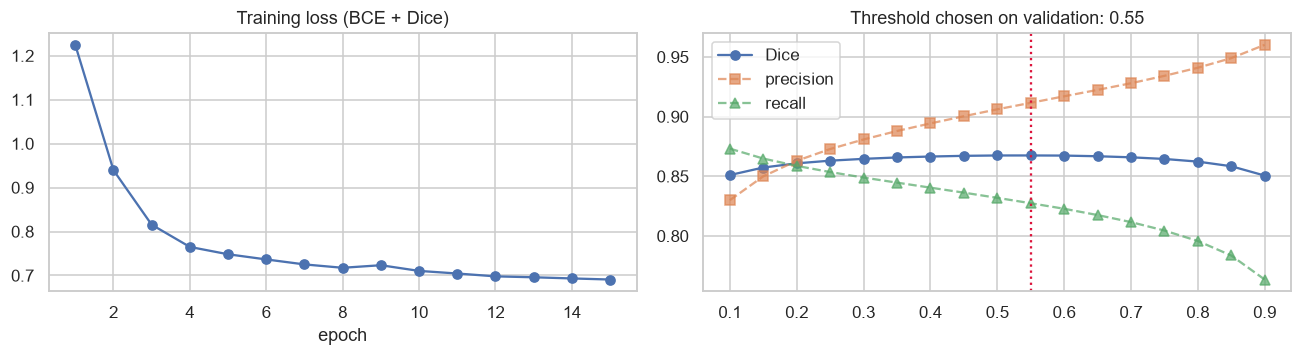

                                micro_dice  micro_iou  micro_precision  micro_recall  macro_dice  pixel_accuracy
method                                                                                                          
A0 predict all background           0.0000     0.0000           0.0000        0.0000      0.8384          0.9859
A1 Otsu on inverted gray            0.0463     0.0237           0.0240        0.6711      0.0947          0.6094
A2 blackhat + global threshold      0.4119     0.2594           0.4520        0.3784      0.6349          0.9847
B per-pixel LogisticRegression      0.4910     0.3254           0.3429        0.8645      0.3137          0.9747
C U-Net                             0.8674     0.7659           0.9115        0.8274      0.7784          0.9964


In [ ]:
val_probabilities = predict_unet_probabilities(unet, val_images, show_progress=True)
candidate_thresholds = np.arange(0.1, 0.95, 0.05)
threshold_sweep = pd.DataFrame([
    dict(threshold=round(float(threshold), 2),
         **segmentation_scores(*confusion_counts(val_probabilities > threshold,
                                                 val_masks)[:3]))
    for threshold in tqdm(candidate_thresholds, desc="threshold sweep")])
BEST_THRESHOLD = float(threshold_sweep.loc[threshold_sweep.dice.idxmax(), "threshold"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(train_history.epoch, train_history.loss, "o-", color="#4C72B0")
axes[0].set_title("Training loss (BCE + Dice)"); axes[0].set_xlabel("epoch")
axes[1].plot(threshold_sweep.threshold, threshold_sweep.dice, "o-", label="Dice")
axes[1].plot(threshold_sweep.threshold, threshold_sweep.precision, "s--", alpha=.7,
             label="precision")
axes[1].plot(threshold_sweep.threshold, threshold_sweep.recall, "^--", alpha=.7,
             label="recall")
axes[1].axvline(BEST_THRESHOLD, color="crimson", ls=":")
axes[1].set_title(f"Threshold chosen on validation: {BEST_THRESHOLD:.2f}")
axes[1].legend()
plt.show()

scores = evaluate_predictions(
    (val_probabilities[i] > BEST_THRESHOLD, val_masks[i])
    for i in range(len(val_masks)))
scores["method"] = "C U-Net"
model_results.append(scores)
comparison_table = pd.DataFrame(model_results).set_index("method")
print(comparison_table[["micro_dice", "micro_iou", "micro_precision", "micro_recall",
                        "macro_dice", "pixel_accuracy"]].round(4).to_string())
comparison_table.to_csv(OUTPUT_DIR / "model_comparison.csv")

**The progression: about 0.41 -> 0.57 -> 0.85 micro Dice.** The gap between B and C is
the informative one - both see the same pixels, but only the U-Net sees a neighbourhood
large enough to tell a dark line from a shadow edge. **Context is what the deep model
contributes.**

**Caveat, stated plainly:** we chose both the epoch and the threshold on validation and
then reported validation, so this number is optimistically biased. The unbiased figure
comes from the untouched test split in the final report.

per-patch Dice:   0%|          | 0/1485 [00:00<?, ?it/s]

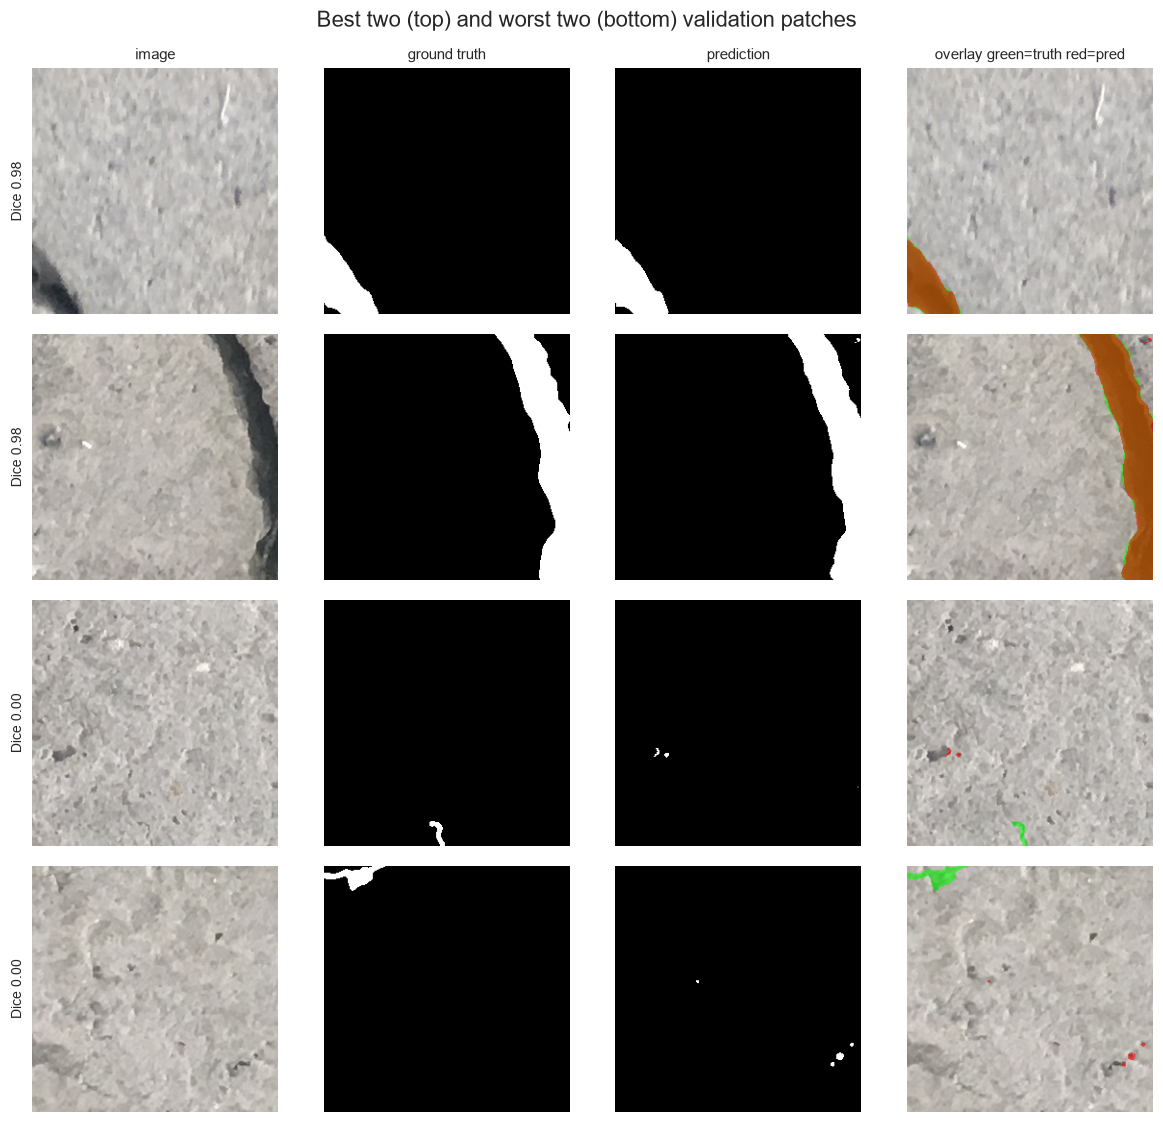

In [ ]:
per_patch_dice = np.array([
    segmentation_scores(*confusion_counts(val_probabilities[i] > BEST_THRESHOLD,
                                          val_masks[i])[:3])["dice"]
    for i in tqdm(range(len(val_masks)), desc="per-patch Dice", leave=False)])
cracked_positions = np.flatnonzero(val_masks.any((1, 2)))
ranked_positions = cracked_positions[np.argsort(per_patch_dice[cracked_positions])]
showcase = list(ranked_positions[-2:][::-1]) + list(ranked_positions[:2])

fig, axes = plt.subplots(len(showcase), 4, figsize=(11, 2.6 * len(showcase)))
for row, patch_position in enumerate(showcase):
    true_mask = val_masks[patch_position]
    pred_mask = val_probabilities[patch_position] > BEST_THRESHOLD
    overlay = val_images[patch_position].copy()
    overlay[true_mask] = (0.45 * overlay[true_mask]
                          + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    overlay[pred_mask] = (0.45 * overlay[pred_mask]
                          + 0.55 * np.array([255, 0, 0])).astype(np.uint8)
    panels = [(val_images[patch_position], None, "image"),
              (true_mask, "gray", "ground truth"),
              (pred_mask, "gray", "prediction"),
              (overlay, None, "overlay green=truth red=pred")]
    for column, (panel, colour_map, label) in enumerate(panels):
        axes[row, column].imshow(panel, cmap=colour_map)
        axes[row, column].axis("off")
        if row == 0:
            axes[row, column].set_title(label, fontsize=10)
    axes[row, 0].text(-0.06, 0.5, f"Dice {per_patch_dice[patch_position]:.2f}",
                      rotation=90, va="center", ha="center",
                      transform=axes[row, 0].transAxes, fontsize=9)
fig.suptitle("Best two (top) and worst two (bottom) validation patches")
plt.show()

**Failure modes**, each pointing at a different fix: very thin low-contrast hairline
cracks, where recall collapses; cracks cut by our patch grid, an artefact of our own
patching and the argument for overlapping tiled inference; dark linear distractors such
as mortar joints and shadows; and cases where the mask is thicker than the crack, so the
"error" is partly in the ground truth.

---
## 12. Explaining the simple model

Our question: **which visual evidence drives the decision, and is it sensible?** The
logistic regression was fitted on standardised features, so its coefficients are
directly comparable - no extra tooling needed.

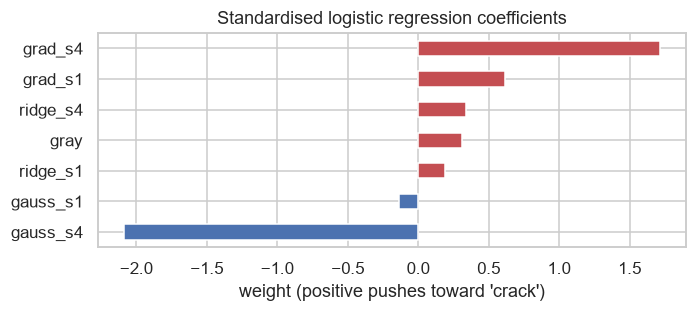

gauss_s4   -2.085
gauss_s1   -0.134
ridge_s1    0.194
gray        0.312
ridge_s4    0.342
grad_s1     0.618
grad_s4     1.713


In [ ]:
coefficients = pd.Series(pixel_logreg.coef_[0],
                         index=FILTER_BANK_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3))
coefficients.plot.barh(ax=ax,
                       color=np.where(coefficients > 0, "#C44E52", "#4C72B0"))
ax.set_title("Standardised logistic regression coefficients")
ax.set_xlabel("weight (positive pushes toward 'crack')")
plt.show()
print(coefficients.round(3).to_string())

The model leans on **darkness** (a negative weight on smoothed intensity: darker pixels
are more likely crack) and on **ridge and gradient responses at both scales**, which is
exactly what one would design by hand for a dark curvilinear structure. Evidence from
more than one scale contributes, matching cracks of varying width.

This also explains why the U-Net wins: our filter bank is fixed, local and capped at
sigma 4, while the U-Net learns its filters and sees far more context.

**Planned:** occlusion sensitivity on the U-Net, and SHAP if time allows.

---
## 13. Tools

Python 3.14; **PyTorch** (CUDA, mixed precision) for the U-Net; **scikit-learn** for the
pixel model, PCA, t-SNE and clustering; **OpenCV** (CLAHE, morphology, Canny) and
**scikit-image** (Hessian, GLCM) for image processing; **ImageHash** for near-duplicate
detection; pandas, NumPy, PyArrow; matplotlib and seaborn; tqdm for progress on
the whole-dataset passes. conda + JupyterLab, NVIDIA RTX 3060 6 GB. Versions in
`requirements.txt`.

Beyond the workshop material this required learning semantic segmentation, U-Net
architectures, overlap-based losses, morphological image processing and EXIF handling.

---
## 14. Limitations

**Data.** 458 images from a single campus, one era, one camera. **No crack-free source
images** - every photo contains a crack, so deployment on clean surfaces is
extrapolation. Masks are lossy JPEG from a single annotator with no agreement estimate,
and are visibly thicker than the cracks, putting an unknown ceiling on achievable Dice.

**Method.** Everything from patching onward uses a **60-image subset** (42 train, 9
validation). The U-Net epoch and threshold were selected on validation and reported on
it, so the headline number is optimistic. Evaluation is patch-level, not whole-image. No
cross-validation of the U-Net and no architecture ablation yet.

---
## 15. Summary and plan for the final project

**Established here:** a verified pipeline over all 458 pairs; a real data defect found
and fixed (EXIF misaligns 194 images, 15 of them invisible to any shape check); the
target quantified (1.1% crack pixels, masks not truly binary, 83.4% empty patches); a
frozen leakage-safe stratified split; an EDA showing hand-crafted descriptors do *not*
separate cracked patches; and three working models with a clear progression.

**Open questions.** Does the U-Net advantage survive if the classical baseline also gets
overlapping tiled inference? Is annotation thickness systematically depressing
precision? Does the model detect cracks, or dark linear structures generally?

**Plan.**
- Scale to all 458 images (~75,600 patches), reusing the frozen split.
- Train the U-Net to convergence; try a pretrained encoder; ablate the loss and the
  patch size.
- Report on the **held-out test split**, once, plus whole-image tiled inference.
- Per-cluster error analysis and a failure taxonomy.
- Occlusion sensitivity for the U-Net; morphological post-processing.